# Advanced Certification in AIML
## A Program by IIIT-H and TalentSprint

## Problem Statement

Perform customer segmentation using bank data into distinct categories based on their behavioral patterns

## Learning Objectives

At the end of the experiment, you will be able to:

* Understand clustering
* Find groups or clusters using K-means algorithm
* Visualize the high-dimensional data to low-dimensional data (2D) by applying t-SNE algorithm

In [ ]:
#@title  Mini Hackathon Walkthrough
from IPython.display import HTML

HTML("""<video width="854" height="480" controls>
  <source src="https://cdn.iiith.talentsprint.com/aiml/Experiment_related_data/Walkthrough/Customer_Segmentation.mp4" type="video/mp4">
</video>
""")

## Domain Information

- **Customer segmentation** refers to the process of dividing a set of potential customers into groups (or segments) based on shared attributes, interests, and behaviors.
- One of the key pain points for bank marketing team is to know their customers and identify their needs.
- For this mini-hackathon, we will use the popular **K-Means clustering** algorithm to segment customers based on their behavior from the bank data. The basic concept is that consumers who share common traits would respond to marketing communication in a similar way so that the bank marketing team can reach out to each group in a relevant and effective way.

## Dataset

### Description

The dataset chosen for this mini hackathon is the behavior of customers in the bank for 6 months, this dataset is made up of 13 features.

**Attribute Information**

- **CUSTID:** Identification of Credit Cardholder
- **BALANCE:** Balance amount left in customer's account to make purchases
- **PURCHASES:** Amount of purchases made from the account
- **INSTALLMENTS_PURCHASES:** Amount of purchase done in installment
- **CASH_ADVANCE:** Cash in advance given by the user
- **PURCHASES_FREQUENCY:** How frequently the Purchases are being made score between 0 and 1 (1 = frequently purchased, 0 = not frequently purchased)
- **CASH_ADVANCE_FREQUENCY:** How frequently the cash in advance being paid
- **CASH_ADVANCE_TRX:** Number of Transactions made with "Cash in Advance"
- **CREDIT_LIMIT:** Limit of Credit Card for user
- **PAYMENTS:** Amount of Payment done by a user
- **MINIMUM_PAYMENTS:** Minimum amount of payments made by a user
- **PRC_FULL_PAYMENT:** Percent of full payment paid by a user
- **TENURE:** Tenure of credit card service for user

**Note:** The currency values mentioned above are in "dollars"

## Grading = 10 Marks

## Setup Steps

In [2]:
#@title Run this cell to complete the setup for this Notebook

from IPython import get_ipython
ipython = get_ipython()

notebook="U2_MH2_Customer_Segmentation" #name of the notebook
Answer = "This notebook is graded by mentors on the day of hackathon"
def setup():
    ipython.magic("sx wget https://cdn.iiith.talentsprint.com/aiml/Experiment_related_data/Marketing_data_clustering.csv")
    print ("Setup completed successfully")
    return

setup()

Setup completed successfully


### Importing Required Packages

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

## **Stage 1:** Data Pre-Processing (2 Marks)

- Replace the missing values in any other column appropriately with mean / median / mode.

  Hint: Use pandas [fillna](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.fillna.html) function to replace the missing values

- Perform correlation on the data features and remove highly correlated features from the data
  
  Hint: Use pandas [corr](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.corr.html)

- Drop any unwanted columns
  
  Hint: Use pandas [drop](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.drop.html)

- Perform `StandardScaler()` on the data features
  
  Hint: Use Sklearns [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)



In [4]:
# YOUR CODE HERE
df=pd.read_csv("/content/Marketing_data_clustering.csv")
df.head()

,CUST_ID,BALANCE,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,95.40,95.4,0.00000,0.166667,0.000000,0,1000.0,201.802084,139.509787,0.0,12
1,C10005,817.714335,16.00,0.0,0.00000,0.083333,0.000000,0,1200.0,678.334763,244.791237,0.0,12
2,C10008,1823.652743,436.20,436.2,0.00000,1.000000,0.000000,0,2300.0,679.065082,532.033990,0.0,12
3,C10009,1014.926473,861.49,200.0,0.00000,0.333333,0.000000,0,7000.0,688.278568,311.963409,0.0,12
4,C10015,2772.772734,0.00,0.0,346.81139,0.000000,0.083333,1,3000.0,805.647974,989.962866,0.0,12


In [5]:
df.shape

(2994, 13)

In [6]:
df['TENURE'].unique()

array([12])

In [7]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0
CASH_ADVANCE_TRX,0
CREDIT_LIMIT,0
PAYMENTS,0


In [8]:
df['MINIMUM_PAYMENTS']=df['MINIMUM_PAYMENTS'].fillna(0)

In [9]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0
CASH_ADVANCE_TRX,0
CREDIT_LIMIT,0
PAYMENTS,0


In [10]:
df.columns

Index(['CUST_ID', 'BALANCE', 'PURCHASES', 'INSTALLMENTS_PURCHASES',
       'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS',
       'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')

In [16]:
features_list=['BALANCE', 'PURCHASES', 'INSTALLMENTS_PURCHASES',
       'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS',
       'PRC_FULL_PAYMENT']

In [12]:
df.describe()

,BALANCE,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,2994.000000,2994.000000,2994.000000,2994.000000,2994.000000,2994.000000,2994.000000,2994.000000,2994.000000,2994.000000,2994.000000,2994.0
mean,1203.715690,375.938988,176.681246,417.120996,0.392006,0.101453,1.777221,3192.027995,815.443883,461.638816,0.028389,12.0
std,1025.943456,443.534594,256.328193,649.995147,0.372497,0.127583,2.423877,2423.088548,696.084869,354.772848,0.068511,0.0
min,1.198223,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,150.000000,0.000000,0.000000,0.000000,12.0
25%,379.893377,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1500.000000,351.734224,194.180470,0.000000,12.0
50%,1036.419148,219.885000,18.230000,38.941802,0.333333,0.083333,1.000000,2500.000000,601.995631,341.896118,0.000000,12.0
75%,1678.253693,574.552500,291.225000,626.843430,0.750000,0.166667,3.000000,4000.000000,1040.778351,628.032529,0.000000,12.0
max,4940.113918,2315.860000,1170.490000,2780.106659,1.000000,0.500000,10.000000,13500.000000,4138.243604,1801.264841,0.333333,12.0


In [17]:
df[features_list].corr()

,BALANCE,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT
BALANCE,1.000000,-0.034273,-0.108315,0.368653,-0.205498,0.346867,0.319499,0.318990,0.206895,0.760175,-0.359114
PURCHASES,-0.034273,1.000000,0.669130,-0.204737,0.604114,-0.256953,-0.222998,0.210281,0.209721,0.012265,0.089057
INSTALLMENTS_PURCHASES,-0.108315,0.669130,1.000000,-0.190027,0.733458,-0.254217,-0.228237,0.086503,0.119167,0.013758,0.153122
CASH_ADVANCE,0.368653,-0.204737,-0.190027,1.000000,-0.309937,0.643990,0.682928,0.082986,0.323777,0.209156,-0.038101
PURCHASES_FREQUENCY,-0.205498,0.604114,0.733458,-0.309937,1.000000,-0.376825,-0.332471,0.033842,0.014541,-0.040756,0.203014
CASH_ADVANCE_FREQUENCY,0.346867,-0.256953,-0.254217,0.643990,-0.376825,1.000000,0.910790,-0.043460,0.173395,0.217498,-0.116330
CASH_ADVANCE_TRX,0.319499,-0.222998,-0.228237,0.682928,-0.332471,0.910790,1.000000,-0.044277,0.183596,0.222975,-0.106766
CREDIT_LIMIT,0.318990,0.210281,0.086503,0.082986,0.033842,-0.043460,-0.044277,1.000000,0.191864,0.101673,0.011315
PAYMENTS,0.206895,0.209721,0.119167,0.323777,0.014541,0.173395,0.183596,0.191864,1.000000,0.185425,0.159018
MINIMUM_PAYMENTS,0.760175,0.012265,0.013758,0.209156,-0.040756,0.217498,0.222975,0.101673,0.185425,1.000000,-0.284642


In [18]:
from sklearn.preprocessing import StandardScaler
scaled=StandardScaler()
X_scaled=scaled.fit_transform(df[features_list])
X_scaled

array([[-1.13359969, -0.63261322, -0.31715131, ..., -0.88170901,
        -0.90813838, -0.41444166],
       [-0.37630323, -0.8116596 , -0.6893926 , ..., -0.19700475,
        -0.61133146, -0.41444166],
       [ 0.60436139,  0.13588811,  1.01261629, ..., -0.19595539,
         0.19845637, -0.41444166],
       ...,
       [-1.15745725,  0.14783957,  0.5467294 , ..., -0.47832047,
        -1.0439698 ,  4.45174987],
       [-1.1077884 , -0.18251679,  0.46166798, ..., -0.81864971,
        -0.83028332,  3.9651351 ],
       [-0.87406153,  1.20272491,  1.26155753, ...,  0.18367824,
        -0.79607955, -0.41444166]])

## **Stage 2:** K Means (3 Marks)

- Find the right number of clusters to be chosen using the elbow method
  
- Perform K-Means on the chosen optimal number of clusters

  **Hint:** Refer to this [link](https://towardsdatascience.com/clustering-algorithms-for-customer-segmentation-af637c6830ac) for finding the k-clusters using elbow method and applying kmeans

In [19]:
# YOUR CODE HERE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import matplotlib.pyplot as plt

# X_scaled --> standardized dataset

inertia = []
sil_scores = []
ch_scores = []

K = range(2, 11)   # K values from 2 to 10

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    # Elbow Method
    inertia.append(kmeans.inertia_)

    # Silhouette Score
    sil_scores.append(silhouette_score(X_scaled, labels))

    # Calinski-Harabasz Score
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))

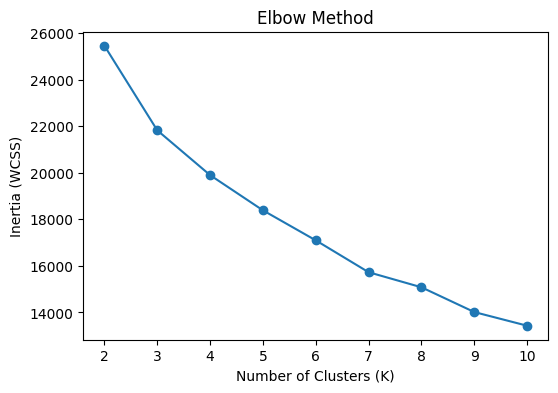

In [20]:
plt.figure(figsize=(6,4))
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method')
plt.show()

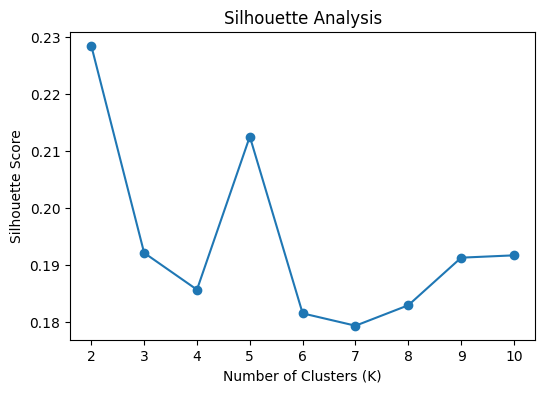

In [21]:
plt.figure(figsize=(6,4))
plt.plot(K, sil_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.show()

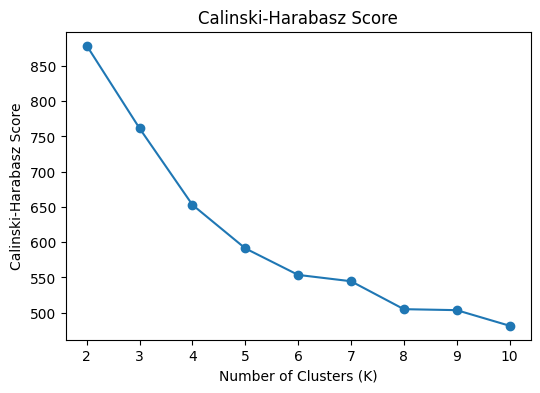

In [22]:
plt.figure(figsize=(6,4))
plt.plot(K, ch_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Calinski-Harabasz Score')
plt.title('Calinski-Harabasz Score')
plt.show()

## **Stage 3:** Apply **TSNE** with 2 components (n_components = 2) and visualize the clusters (3 Marks)

Hint: Use Sklearns [TSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)

**Note:** Produce a visualization with distinctly isolated clusters and It is not necessary to plot the centroids



In [ ]:
# YOUR CODE HERE

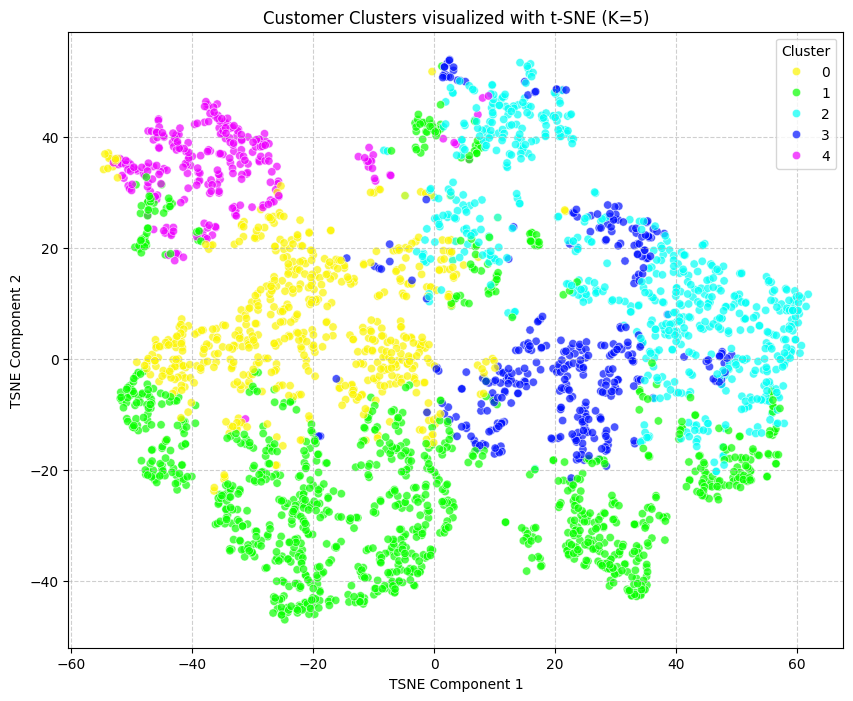

In [25]:
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Apply KMeans with the recommended number of clusters (K=5 as per your last edit)
kmeans_optimal = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans_optimal.fit_predict(X_scaled)

# Apply t-SNE with 2 components for visualization
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Create a DataFrame for visualization
tsne_df = pd.DataFrame(data=X_tsne, columns=['TSNE_Component_1', 'TSNE_Component_2'])
tsne_df['Cluster'] = labels

# Visualize the clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='TSNE_Component_1', y='TSNE_Component_2',
    hue='Cluster',
    palette=sns.color_palette('hsv', n_colors=len(tsne_df['Cluster'].unique())),
    data=tsne_df,
    legend='full',
    alpha=0.7
)
plt.title('Customer Clusters visualized with t-SNE (K=5)')
plt.xlabel('TSNE Component 1')
plt.ylabel('TSNE Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## **Stage 4:** Insights for each cluster

#### **Stage 4(a)** (1 Mark):
- To understand the behavior of the customers from each cluster print the respective centroid point values obtained from the scaled dataframe
- Get the original representation of the scaled centroid points using [inverse_transformation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler.inverse_transform) technique

In [ ]:
# YOUR CODE HERE

In [26]:
# Get the scaled cluster centroids
scaled_centroids = kmeans_optimal.cluster_centers_

# Inverse transform the scaled centroids to their original scale
original_centroids = scaled.inverse_transform(scaled_centroids)

# Create a DataFrame for better readability
centroids_df = pd.DataFrame(original_centroids, columns=features_list)

print("Original Centroid Values for Each Cluster:")
display(centroids_df)

Original Centroid Values for Each Cluster:


,BALANCE,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT
0,1093.117333,907.792626,539.235017,126.427874,0.839506,0.034231,0.572391,3458.976125,974.995088,511.171928,0.011330
1,843.490759,226.273615,59.933075,114.214410,0.266478,0.044715,0.635017,2589.329268,513.209402,337.923881,0.008652
2,1331.950851,154.955620,49.971680,1156.008346,0.148744,0.269754,5.086342,2553.218210,1049.808848,444.968270,0.022144
3,3089.621400,262.088123,77.093249,795.707418,0.237628,0.153128,2.602241,5549.439776,1172.344954,1021.973855,0.002363
4,135.031615,520.535698,312.095465,86.043014,0.734496,0.021641,0.321705,3574.418605,720.434588,163.893099,0.206919


#### **Stage 4(b)** (1 Mark):
- Report your observations in the form of text, about the customers based on the centroid points

Hint: If require use [clustermap](https://seaborn.pydata.org/generated/seaborn.clustermap.html)

#### **Cluster Analysis based on Centroid Values:**

By examining the centroid values for each of the five clusters, we can characterize distinct customer segments:

*   **Cluster 0: High Spenders with High Credit Limits and Moderate Payments**
    *   This segment shows high values for `BALANCE`, `PURCHASES`, and `INSTALLMENTS_PURCHASES`, indicating active use of credit for various transactions.
    *   They also have the highest `CREDIT_LIMIT` and `PAYMENTS`, suggesting they manage a higher line of credit and make substantial payments.
    *   Their `PURCHASES_FREQUENCY` is high, but `CASH_ADVANCE` related metrics are relatively low.
    *   This group seems to be **"High-Value Purchasers"** who utilize their credit cards for shopping and installment plans.

*   **Cluster 1: Cautious Low-Activity Users**
    *   This cluster generally has lower values across most features, including `BALANCE`, `PURCHASES`, `CASH_ADVANCE`, and `CREDIT_LIMIT`.
    *   Their `PURCHASES_FREQUENCY` is also low, and `CASH_ADVANCE_FREQUENCY` is minimal.
    *   They tend to make lower `PAYMENTS` and have lower `MINIMUM_PAYMENTS`.
    *   This segment represents **"Infrequent or New Users"** who use their cards sparingly or have lower credit needs.

*   **Cluster 2: High Cash Advance Users**
    *   This cluster stands out with the highest values for `CASH_ADVANCE`, `CASH_ADVANCE_FREQUENCY`, and `CASH_ADVANCE_TRX`.
    *   Their `PURCHASES` and `INSTALLMENTS_PURCHASES` are significantly lower compared to `CASH_ADVANCE` usage.
    *   They have moderate `BALANCE` and `CREDIT_LIMIT` but relatively high `PAYMENTS`, potentially to manage their cash advance debt.
    *   This group is best described as **"Cash-Dependent Users"** who frequently rely on cash advances.

*   **Cluster 3: High Balance, High Credit Limit, and High Minimum Payments**
    *   This cluster has the highest `BALANCE` and `CREDIT_LIMIT` among all segments.
    *   They have moderate `CASH_ADVANCE` usage but their `PURCHASES` are low. They also have the highest `MINIMUM_PAYMENTS`.
    *   `PRC_FULL_PAYMENT` is very low, indicating they rarely pay their full balance.
    *   This segment could be categorized as **"High-Debt, Minimum Payment Users"** who carry large balances and might be struggling to pay them off fully.

*   **Cluster 4: Active Purchasers with High Full Payment Tendency**
    *   This cluster has a relatively low `BALANCE` and `CASH_ADVANCE` usage.
    *   They show good `PURCHASES` and `INSTALLMENTS_PURCHASES`, coupled with the highest `PURCHASES_FREQUENCY`.
    *   Crucially, this group has the highest `PRC_FULL_PAYMENT`, indicating a strong tendency to pay off their balance in full.
    *   They represent **"Responsible & Frequent Purchasers"** who actively use their cards but maintain good financial habits.

#### **Detailed Feature Contribution to Each Cluster:**

Let's break down the most influential features for each cluster directly from the `centroids_df`:

*   **Cluster 0: "High-Value Purchasers"**
    *   **High:** `PURCHASES`, `INSTALLMENTS_PURCHASES`, `PURCHASES_FREQUENCY`, `CREDIT_LIMIT`, `PAYMENTS`, `BALANCE`
    *   **Low:** `CASH_ADVANCE`, `CASH_ADVANCE_FREQUENCY`, `CASH_ADVANCE_TRX`, `PRC_FULL_PAYMENT` (relatively)
    *   **Key takeaway:** These customers actively use their credit for various types of purchases (especially installments) and manage high credit limits, but they don't frequently pay their balance in full.

*   **Cluster 1: "Infrequent or New Users"**
    *   **Low:** `BALANCE`, `PURCHASES`, `INSTALLMENTS_PURCHASES`, `CASH_ADVANCE`, `PURCHASES_FREQUENCY`, `CASH_ADVANCE_FREQUENCY`, `CASH_ADVANCE_TRX`, `CREDIT_LIMIT`, `PAYMENTS`, `MINIMUM_PAYMENTS`, `PRC_FULL_PAYMENT`
    *   **Key takeaway:** This is the least active group across almost all metrics, suggesting they are either new customers, very cautious users, or have very low credit needs.

*   **Cluster 2: "Cash-Dependent Users"**
    *   **High:** `CASH_ADVANCE`, `CASH_ADVANCE_FREQUENCY`, `CASH_ADVANCE_TRX`
    *   **Low:** `PURCHASES`, `INSTALLMENTS_PURCHASES`, `PURCHASES_FREQUENCY`, `PRC_FULL_PAYMENT` (very low)
    *   **Moderate:** `BALANCE`, `CREDIT_LIMIT`, `PAYMENTS`
    *   **Key takeaway:** The defining characteristic is their heavy reliance on cash advances, with minimal general purchasing activity. They make moderate payments, possibly to keep up with their cash advance debts.

*   **Cluster 3: "High-Debt, Minimum Payment Users"**
    *   **Highest:** `BALANCE`, `CREDIT_LIMIT`, `MINIMUM_PAYMENTS`
    *   **High:** `CASH_ADVANCE` (moderate to high)
    *   **Very Low:** `PRC_FULL_PAYMENT` (lowest among all clusters)
    *   **Low:** `PURCHASES`, `INSTALLMENTS_PURCHASES`, `PURCHASES_FREQUENCY`
    *   **Key takeaway:** These customers carry the highest balances and have high credit limits, often making only minimum payments and rarely paying in full. They appear to be in a debt-accruing pattern.

*   **Cluster 4: "Responsible & Frequent Purchasers"**
    *   **High:** `PURCHASES`, `INSTALLMENTS_PURCHASES`, `PURCHASES_FREQUENCY`, `PRC_FULL_PAYMENT` (highest)
    *   **Low:** `BALANCE`, `CASH_ADVANCE`, `CASH_ADVANCE_FREQUENCY`, `CASH_ADVANCE_TRX`, `MINIMUM_PAYMENTS`
    *   **Key takeaway:** This segment actively uses their credit for purchases and installment plans but demonstrates excellent financial habits by frequently paying their balance in full, leading to low balances.

#### **Sample Customers from Each Cluster:**

To give you a better feel for each segment, here are a few actual customer profiles from each cluster. We will display the original (unscaled) feature values for these samples.

In [27]:
# Add the cluster labels to the original DataFrame
df['Cluster'] = labels

# Display a few samples from each cluster
print("\n--- Sample Customers for Each Cluster ---")
for i in range(5):
    print(f"\nCluster {i} Samples (first 3 rows):")
    display(df[df['Cluster'] == i][features_list].head(3))


--- Sample Customers for Each Cluster ---

Cluster 0 Samples (first 3 rows):


,BALANCE,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT
2,1823.652743,436.20,436.2,0.0,1.000000,0.0,0,2300.0,679.065082,532.033990,0.0
6,169.781679,399.60,399.6,0.0,1.000000,0.0,0,3000.0,215.306142,163.005536,0.0
23,1699.435486,1363.69,0.0,0.0,0.333333,0.0,0,1700.0,1623.816348,923.505868,0.0



Cluster 1 Samples (first 3 rows):


,BALANCE,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT
0,40.900749,95.40,95.4,0.0,0.166667,0.0,0,1000.0,201.802084,139.509787,0.0
1,817.714335,16.00,0.0,0.0,0.083333,0.0,0,1200.0,678.334763,244.791237,0.0
3,1014.926473,861.49,200.0,0.0,0.333333,0.0,0,7000.0,688.278568,311.963409,0.0



Cluster 2 Samples (first 3 rows):


,BALANCE,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT
7,1615.967240,102.0,0.0,244.840485,0.166667,0.25,5,1700.0,890.178845,971.183209,0.0
14,3910.111237,0.0,0.0,1980.873201,0.000000,0.50,7,4200.0,0.000000,0.000000,0.0
16,1565.681099,0.0,0.0,321.359135,0.000000,0.25,3,3500.0,691.825279,581.481917,0.0



Cluster 3 Samples (first 3 rows):


,BALANCE,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT
4,2772.772734,0.00,0.00,346.81139,0.000000,0.083333,1,3000.0,805.647974,989.962866,0.0
5,1989.072228,504.35,338.35,0.00000,0.666667,0.000000,0,13000.0,1720.837373,744.613395,0.0
11,4104.710798,203.82,0.00,0.00000,0.083333,0.000000,0,4500.0,868.275275,1801.264841,0.0



Cluster 4 Samples (first 3 rows):


,BALANCE,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT
25,17.357563,244.85,204.64,0.000000,0.666667,0.000000,0,5000.0,357.802082,121.523416,0.181818
85,19.508047,193.14,193.14,0.000000,0.416667,0.000000,0,2000.0,220.463770,71.965063,0.250000
95,272.711518,0.00,0.00,682.156051,0.000000,0.083333,2,3000.0,2755.877257,144.621645,0.181818


In [28]:
print(f"\nCluster 3 Samples (first 3 rows):")
display(df[df['Cluster'] == 3][features_list].head(3))

print(f"\nCluster 4 Samples (first 3 rows):")
display(df[df['Cluster'] == 4][features_list].head(3))


Cluster 3 Samples (first 3 rows):


,BALANCE,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT
4,2772.772734,0.00,0.00,346.81139,0.000000,0.083333,1,3000.0,805.647974,989.962866,0.0
5,1989.072228,504.35,338.35,0.00000,0.666667,0.000000,0,13000.0,1720.837373,744.613395,0.0
11,4104.710798,203.82,0.00,0.00000,0.083333,0.000000,0,4500.0,868.275275,1801.264841,0.0



Cluster 4 Samples (first 3 rows):


,BALANCE,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT
25,17.357563,244.85,204.64,0.000000,0.666667,0.000000,0,5000.0,357.802082,121.523416,0.181818
85,19.508047,193.14,193.14,0.000000,0.416667,0.000000,0,2000.0,220.463770,71.965063,0.250000
95,272.711518,0.00,0.00,682.156051,0.000000,0.083333,2,3000.0,2755.877257,144.621645,0.181818


In [ ]:
# YOUR ANALYSIS HERE